In [2]:
import pandas as pd
from IPython.display import display

# CSV files
listings_df = pd.read_csv("data/listings.csv")
neighbourhoods_df = pd.read_csv("data/neighbourhoods.csv")
reviews_df = pd.read_csv("data/reviews.csv")

# Compressed CSV files
calendar_gz_df = pd.read_csv("data/calendar.csv.gz")
listings_gz_df = pd.read_csv("data/listings.csv.gz")
reviews_gz_df = pd.read_csv("data/reviews.csv.gz")

# GeoJSON file
neighbourhoods_geojson_df = pd.read_json("data/neighbourhoods.geojson")

print("Loaded dataframes:")
print("- listings_df:", listings_df.shape)
print("- neighbourhoods_df:", neighbourhoods_df.shape)
print("- reviews_df:", reviews_df.shape)
print("- calendar_gz_df:", calendar_gz_df.shape)
print("- listings_gz_df:", listings_gz_df.shape)
print("- reviews_gz_df:", reviews_gz_df.shape)
print("- neighbourhoods_geojson_df:", neighbourhoods_geojson_df.shape)

Loaded dataframes:
- listings_df: (12252, 18)
- neighbourhoods_df: (62, 2)
- reviews_df: (469309, 2)
- calendar_gz_df: (4471980, 7)
- listings_gz_df: (12252, 79)
- reviews_gz_df: (469309, 6)
- neighbourhoods_geojson_df: (62, 2)


In [6]:
display(listings_df.head(), listings_df.info(), listings_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 12252 entries, 0 to 12251
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              12252 non-null  int64  
 1   name                            12252 non-null  str    
 2   host_id                         12252 non-null  int64  
 3   host_name                       12249 non-null  str    
 4   neighbourhood_group             12252 non-null  str    
 5   neighbourhood                   12252 non-null  str    
 6   latitude                        12252 non-null  float64
 7   longitude                       12252 non-null  float64
 8   room_type                       12252 non-null  str    
 9   price                           7778 non-null   float64
 10  minimum_nights                  12252 non-null  int64  
 11  number_of_reviews               12252 non-null  int64  
 12  last_review                     10334 non-n

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,222887,"Spectacular view, full air-con, elevator",1156398,Suzanne,Bordeaux,Bordeaux Sud,44.836102,-0.566395,Entire home/apt,241.0,3,133,2025-09-04,0.80,4,296,28,3306300031048
1,317273,"Luxury, spacious, patio, near public gardens",1156398,Suzanne,Bordeaux,Chartrons - Grand Parc - Jardin Public,44.847801,-0.581046,Entire home/apt,214.0,3,87,2025-09-03,0.64,4,299,19,33063001366CB
2,317658,"Key to Bordeaux · fairytale view, 2 bd + elevator",1156398,Suzanne,Bordeaux,Centre ville (Bordeaux),44.838799,-0.568870,Entire home/apt,246.0,3,164,2025-08-06,1.00,4,290,14,33063001225CF
3,333031,STUDIO BORDEAUX TRIANGLE D OR ***** Climatisé,1697156,Antony,Bordeaux,Centre ville (Bordeaux),44.842560,-0.577940,Entire home/apt,104.0,1,582,2025-09-03,3.55,2,346,69,3306300055979
4,365993,Modern&comfortable 3 rooms apart,1847986,Damien,Bgles,Bgles,44.811490,-0.558250,Entire home/apt,77.0,5,73,2025-09-03,0.45,2,271,10,NaN


None

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,1.225200e+04,1.225200e+04,12252.000000,12252.000000,7778.000000,12252.000000,12252.000000,10334.000000,12252.000000,12252.000000,12252.000000
mean,5.587934e+17,1.625091e+08,44.840689,-0.587680,128.207765,38.976657,38.304685,1.243841,4.178257,141.189112,8.178746
std,5.712425e+17,1.821497e+08,0.031178,0.046207,469.082029,107.269292,85.210006,1.733380,11.496372,139.960966,16.724565
min,2.228870e+05,3.037400e+04,44.750530,-0.831114,9.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.835232e+07,2.932123e+07,44.824677,-0.603680,53.000000,1.000000,2.000000,0.180000,1.000000,0.000000,0.000000
50%,6.081912e+17,7.671834e+07,44.839107,-0.577199,79.000000,2.000000,10.000000,0.620000,1.000000,89.000000,1.000000
75%,1.115376e+18,2.359730e+08,44.855840,-0.564539,126.000000,5.000000,38.000000,1.670000,2.000000,272.000000,9.000000
max,1.511577e+18,7.191697e+08,45.018548,-0.464280,23700.000000,999.000000,2958.000000,57.920000,84.000000,365.000000,659.000000


In [ ]:
display(neighbourhoods_df.head(), neighbourhoods_df.info(), neighbourhoods_df.describe())

In [3]:
# 1) Chargement et inspection des données (version pandas)
import pandas as pd
import numpy as np

# Chargement
dfs = {
    "listings": pd.read_csv("data/listings.csv"),
    "neighbourhoods": pd.read_csv("data/neighbourhoods.csv"),
    "reviews": pd.read_csv("data/reviews.csv"),
    "calendar": pd.read_csv("data/calendar.csv.gz"),
    "listings_full": pd.read_csv("data/listings.csv.gz"),
    "reviews_full": pd.read_csv("data/reviews.csv.gz"),
    "neighbourhoods_geojson": pd.read_json("data/neighbourhoods.geojson"),
}

# Inspection structure / types (robuste aux colonnes dict/list)
schema_parts = {}
for name, df in dfs.items():
    n_unique = df.apply(
        lambda s: s.nunique(dropna=False)
        if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_datetime64_any_dtype(s)
        else s.astype(str).nunique(dropna=False)
    )
    schema_parts[name] = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2),
            "n_unique": n_unique,
        }
    )

schema = pd.concat(schema_parts, names=["dataset", "column"])

print("=== Dimensions ===")
print(pd.DataFrame({k: [v.shape[0], v.shape[1]] for k, v in dfs.items()}, index=["rows", "cols"]).T)

print("\n=== Extrait du schéma (20 premières lignes) ===")
print(schema.head(20))

# Clés primaires candidates
pk_checks = pd.DataFrame(
    [
        ("listings", "id", dfs["listings"]["id"].is_unique if "id" in dfs["listings"].columns else False),
        ("listings_full", "id", dfs["listings_full"]["id"].is_unique if "id" in dfs["listings_full"].columns else False),
        ("reviews", "id", dfs["reviews"]["id"].is_unique if "id" in dfs["reviews"].columns else False),
        ("reviews_full", "id", dfs["reviews_full"]["id"].is_unique if "id" in dfs["reviews_full"].columns else False),
    ],
    columns=["dataset", "candidate_key", "is_unique"],
)

if {"listing_id", "date"}.issubset(dfs["calendar"].columns):
    calendar_key_unique = ~dfs["calendar"].duplicated(["listing_id", "date"]).any()
    pk_checks.loc[len(pk_checks)] = ["calendar", "(listing_id, date)", calendar_key_unique]

print("\n=== Clés primaires candidates ===")
print(pk_checks)

# Relations entre jeux de données
relations = pd.DataFrame(
    {
        "relation": [
            "calendar.listing_id -> listings_full.id",
            "reviews_full.listing_id -> listings_full.id",
        ],
        "match_pct": [
            (dfs["calendar"]["listing_id"].isin(dfs["listings_full"]["id"]).mean() * 100)
            if {"listing_id"}.issubset(dfs["calendar"].columns) and {"id"}.issubset(dfs["listings_full"].columns)
            else np.nan,
            (dfs["reviews_full"]["listing_id"].isin(dfs["listings_full"]["id"]).mean() * 100)
            if {"listing_id"}.issubset(dfs["reviews_full"].columns) and {"id"}.issubset(dfs["listings_full"].columns)
            else np.nan,
        ],
    }
)

print("\n=== Relations (taux de correspondance) ===")
print(relations)

# Variables pertinentes pour l'offre de logements
target_vars = {
    "listings_full": ["id", "price", "room_type", "property_type", "neighbourhood_cleansed", "accommodates", "minimum_nights", "availability_365"],
    "calendar": ["listing_id", "date", "available", "price", "adjusted_price", "minimum_nights", "maximum_nights"],
    "reviews_full": ["listing_id", "date", "comments"],
}

print("\n=== Variables pertinentes présentes ===")
for name, cols in target_vars.items():
    present = pd.Index(cols).intersection(dfs[name].columns)
    print(f"- {name}: {present.tolist()}")

# Raccourcis pour les étapes suivantes
listings_clean = dfs["listings_full"].copy()
calendar_clean = dfs["calendar"].copy()
reviews_clean = dfs["reviews_full"].copy()

=== Dimensions ===
                           rows  cols
listings                  12252    18
neighbourhoods               62     2
reviews                  469309     2
calendar                4471980     7
listings_full             12252    79
reviews_full             469309     6
neighbourhoods_geojson       62     2

=== Extrait du schéma (20 premières lignes) ===
                                                 dtype  missing  missing_pct  \
dataset        column                                                          
listings       id                                int64        0         0.00   
               name                                str        0         0.00   
               host_id                           int64        0         0.00   
               host_name                           str        3         0.02   
               neighbourhood_group                 str        0         0.00   
               neighbourhood                       str        0     

In [4]:
# 2) Nettoyage et préparation (fonctions pandas)

def clean_price(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce",
    )

# Prix en numérique
listings_clean = listings_clean.assign(
    price=clean_price(listings_clean["price"]) if "price" in listings_clean.columns else np.nan
)

for col in ["price", "adjusted_price"]:
    if col in calendar_clean.columns:
        calendar_clean[col] = clean_price(calendar_clean[col])

# Dates en datetime
for df in [calendar_clean, reviews_clean]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Colonnes numériques souvent importées en texte
for col in ["minimum_nights", "maximum_nights", "availability_365", "accommodates", "listing_id", "id"]:
    if col in listings_clean.columns:
        listings_clean[col] = pd.to_numeric(listings_clean[col], errors="coerce")
    if col in calendar_clean.columns:
        calendar_clean[col] = pd.to_numeric(calendar_clean[col], errors="coerce")
    if col in reviews_clean.columns:
        reviews_clean[col] = pd.to_numeric(reviews_clean[col], errors="coerce")

# Valeurs manquantes quartier
if "neighbourhood_cleansed" in listings_clean.columns:
    listings_clean["neighbourhood_cleansed"] = listings_clean["neighbourhood_cleansed"].fillna("Unknown")

# Valeurs aberrantes sur les prix: clipping IQR
for df, col in [(listings_clean, "price"), (calendar_clean, "price")]:
    if col in df.columns and df[col].notna().any():
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        df[col] = df[col].clip(lower=low, upper=high)

quality_report = pd.concat(
    {
        "listings_clean": listings_clean.isna().sum(),
        "calendar_clean": calendar_clean.isna().sum(),
        "reviews_clean": reviews_clean.isna().sum(),
    },
    axis=1,
).fillna(0).astype(int)

print("=== Qualité des données (NA par colonne, top 15) ===")
print(quality_report.sort_values(by=list(quality_report.columns), ascending=False).head(15))

print("\n=== Types après conversion (extrait) ===")
print(listings_clean.dtypes.head(10))
print(calendar_clean.dtypes.head(10))
print(reviews_clean.dtypes.head(10))

=== Qualité des données (NA par colonne, top 15) ===
                         listings_clean  calendar_clean  reviews_clean
calendar_updated                  12252               0              0
host_neighbourhood                 9813               0              0
host_about                         7678               0              0
license                            7444               0              0
neighborhood_overview              6395               0              0
neighbourhood                      6395               0              0
price                              4474         4471980              0
estimated_revenue_l365d            4474               0              0
beds                               4461               0              0
bathrooms                          4440               0              0
host_response_time                 4409               0              0
host_response_rate                 4409               0              0
host_acceptance_rate    

In [5]:
# 3) Fusion listings + calendar pour calculer un taux d'occupation

# Convention: available == True => nuit libre ; occupied_night=1 si indisponible (donc potentiellement occupée)
calendar_features = (
    calendar_clean
    .assign(
        available_flag=lambda d: d["available"].astype(str).str.lower().str.strip().isin(["t", "true", "1", "yes"]) if "available" in d.columns else False,
        occupied_night=lambda d: (~d["available_flag"]).astype(int),
        listing_id=lambda d: pd.to_numeric(d["listing_id"], errors="coerce") if "listing_id" in d.columns else np.nan,
    )
)

occupancy_by_listing = (
    calendar_features
    .dropna(subset=["listing_id"])
    .groupby("listing_id", as_index=False)
    .agg(
        nights_observed=("occupied_night", "count"),
        nights_occupied=("occupied_night", "sum"),
        avg_calendar_price=("price", "mean"),
    )
    .assign(occupancy_rate=lambda d: d["nights_occupied"] / d["nights_observed"])
)

listings_features = listings_clean.assign(
    id=lambda d: pd.to_numeric(d["id"], errors="coerce") if "id" in d.columns else np.nan
)

listing_enriched = listings_features.merge(
    occupancy_by_listing,
    left_on="id",
    right_on="listing_id",
    how="left",
)

print("=== Jeu enrichi ===")
print(listing_enriched.shape)

by_neighbourhood = (
    listing_enriched
    .groupby("neighbourhood_cleansed", dropna=False)
    .agg(
        listings=("id", "count"),
        avg_listing_price=("price", "mean"),
        avg_calendar_price=("avg_calendar_price", "mean"),
        avg_occupancy_rate=("occupancy_rate", "mean"),
    )
    .sort_values("avg_occupancy_rate", ascending=False)
)

by_room_type = (
    listing_enriched
    .groupby("room_type", dropna=False)
    .agg(
        listings=("id", "count"),
        avg_listing_price=("price", "mean"),
        avg_occupancy_rate=("occupancy_rate", "mean"),
    )
    .sort_values("avg_occupancy_rate", ascending=False)
)

print("\n=== Top 15 quartiers par taux d'occupation moyen ===")
print(by_neighbourhood.head(15))

print("\n=== Taux d'occupation moyen par type de logement ===")
print(by_room_type)

# Objets utiles pour la suite
analysis_tables = {
    "listing_enriched": listing_enriched,
    "by_neighbourhood": by_neighbourhood,
    "by_room_type": by_room_type,
}

=== Jeu enrichi ===
(12252, 84)

=== Top 15 quartiers par taux d'occupation moyen ===
                                           listings  avg_listing_price  \
neighbourhood_cleansed                                                   
Cap de Bos                                       14          69.222222   
Saint-Louis-de-Montferrand                       15          82.916667   
Talence                                         623          81.924202   
Nansouty - Saint Gens                           494          93.989170   
Bordeaux Maritime                               624          94.011527   
La Bastide                                      452          97.098940   
Le Monteil                                       57          85.181818   
La Paillre-Compostelle                           14          77.750000   
Le Burck                                         23          70.375000   
Plaisance-Loret-Maregue                          64          72.432432   
Le Bouscat                

In [12]:
# 3.1 Distribution des prix par type de logement et quartier

price_base = listing_enriched.copy()

# On garde les lignes exploitables
price_base = price_base.dropna(subset=["price", "room_type"])

# Distribution par type de logement
price_dist_room = (
    price_base
    .groupby("room_type")
    .agg(
        n=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        q10=("price", lambda s: s.quantile(0.10)),
        q25=("price", lambda s: s.quantile(0.25)),
        q75=("price", lambda s: s.quantile(0.75)),
        q90=("price", lambda s: s.quantile(0.90)),
    )
    .sort_values("median_price", ascending=False)
)

# Distribution par quartier (avec seuil min d'annonces pour éviter les petits échantillons)
min_listings = 30
price_dist_neighbourhood = (
    price_base
    .groupby("neighbourhood_cleansed")
    .agg(
        n=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        q25=("price", lambda s: s.quantile(0.25)),
        q75=("price", lambda s: s.quantile(0.75)),
    )
    .query("n >= @min_listings")
    .sort_values("median_price", ascending=False)
)

print("=== Distribution des prix par type de logement ===")
print(price_dist_room)

print("\n=== Top 20 quartiers (médiane de prix, n >= 30) ===")
print(price_dist_neighbourhood.head(20))

=== Distribution des prix par type de logement ===
                    n  mean_price  median_price   q10   q25    q75    q90
room_type                                                                
Hotel room         13  152.538462         162.0  74.0  91.0  235.5  235.5
Entire home/apt  6012  111.039088          90.0  50.0  64.0  144.0  235.5
Private room     1712   56.588201          45.0  29.0  36.0   60.0  100.0
Shared room        41   38.536585          25.0  24.0  25.0   40.0   60.0

=== Top 20 quartiers (médiane de prix, n >= 30) ===
                                              n  mean_price  median_price  \
neighbourhood_cleansed                                                      
Saint-Aubin-de-Mdoc                          60  142.683333         146.5   
Bouliac                                      41  147.560976         135.0   
Chartrons - Grand Parc - Jardin Public      504  116.249008         100.0   
Centre ville (Bordeaux)                    1111  116.805581        

In [13]:
# 3.4 Distribution des avis dans le temps et indicateurs par logement/type

reviews_ts = (
    reviews_clean
    .assign(
        date=lambda d: pd.to_datetime(d["date"], errors="coerce"),
        listing_id=lambda d: pd.to_numeric(d["listing_id"], errors="coerce"),
    )
    .dropna(subset=["date", "listing_id"])
)

# Nombre d'avis par logement
reviews_per_listing = (
    reviews_ts
    .groupby("listing_id", as_index=False)
    .size()
    .rename(columns={"size": "n_reviews"})
)

reviews_per_listing_dist = reviews_per_listing["n_reviews"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])

# Avis dans le temps
reviews_monthly = (
    reviews_ts
    .assign(year_month=lambda d: d["date"].dt.to_period("M"))
    .groupby("year_month", as_index=False)
    .agg(n_reviews=("listing_id", "count"))
    .sort_values("year_month")
)

# Note moyenne par type de logement (via listings)
rating_col = "review_scores_rating"
rating_by_room_type = pd.DataFrame()
if rating_col in listings_clean.columns and "room_type" in listings_clean.columns:
    rating_by_room_type = (
        listings_clean
        .assign(rating=lambda d: pd.to_numeric(d[rating_col], errors="coerce"))
        .dropna(subset=["rating", "room_type"])
        .groupby("room_type", as_index=False)
        .agg(
            mean_rating=("rating", "mean"),
            median_rating=("rating", "median"),
            n_listings=("id", "count"),
        )
        .sort_values("mean_rating", ascending=False)
    )

print("=== Distribution du nombre d'avis par logement ===")
print(reviews_per_listing_dist)

print("\n=== Avis mensuels (12 derniers mois disponibles) ===")
print(reviews_monthly.tail(12))

print("\n=== Note moyenne par type de logement ===")
print(rating_by_room_type if not rating_by_room_type.empty else "Colonne review_scores_rating absente de listings_clean")

=== Distribution du nombre d'avis par logement ===
count    10334.000000
mean        45.414070
std         91.025157
min          1.000000
10%          2.000000
25%          5.000000
50%         16.000000
75%         47.000000
90%        110.000000
max       2958.000000
Name: n_reviews, dtype: float64

=== Avis mensuels (12 derniers mois disponibles) ===
    year_month  n_reviews
152    2024-10       8560
153    2024-11       6312
154    2024-12       5990
155    2025-01       5269
156    2025-02       5642
157    2025-03       6883
158    2025-04       8567
159    2025-05       9374
160    2025-06      11062
161    2025-07      10120
162    2025-08      14201
163    2025-09       3880

=== Note moyenne par type de logement ===
         room_type  mean_rating  median_rating  n_listings
2     Private room     4.791746          4.890        2090
0  Entire home/apt     4.775860          4.860        8198
1       Hotel room     4.706667          4.745          12
3      Shared room     4.4

In [17]:
# 3.3 Évolution temporelle des disponibilités et des prix (saisonnalité)

calendar_ts = (
    calendar_clean
    .assign(
        date=lambda d: pd.to_datetime(d["date"], errors="coerce"),
        price_num=lambda d: pd.to_numeric(d["price"], errors="coerce") if "price" in d.columns else np.nan,
        adjusted_price_num=lambda d: pd.to_numeric(d["adjusted_price"], errors="coerce") if "adjusted_price" in d.columns else np.nan,
        available_flag=lambda d: d["available"].astype(str).str.lower().str.strip().isin(["t", "true", "1", "yes"]),
    )
    .assign(effective_price=lambda d: d["price_num"].combine_first(d["adjusted_price_num"]))
    .dropna(subset=["date"])
    .assign(
        year_month=lambda d: d["date"].dt.to_period("M"),
        month_num=lambda d: d["date"].dt.month,
    )
)

price_non_null = calendar_ts["effective_price"].notna().sum()
print(f"Lignes calendrier avec prix exploitable: {price_non_null} / {len(calendar_ts)}")

# Évolution mensuelle
monthly_calendar = (
    calendar_ts
    .groupby("year_month", as_index=False)
    .agg(
        availability_rate=("available_flag", "mean"),
        n_rows=("listing_id", "count"),
    )
    .sort_values("year_month")
)
monthly_calendar["occupancy_proxy"] = 1 - monthly_calendar["availability_rate"]

if price_non_null > 0:
    monthly_price = (
        calendar_ts
        .dropna(subset=["effective_price"])
        .groupby("year_month", as_index=False)
        .agg(
            avg_price=("effective_price", "mean"),
            median_price=("effective_price", "median"),
        )
    )
    monthly_calendar = monthly_calendar.merge(monthly_price, on="year_month", how="left")
else:
    monthly_calendar["avg_price"] = np.nan
    monthly_calendar["median_price"] = np.nan

# Saisonnalité par mois calendaire
seasonality_month = (
    calendar_ts
    .groupby("month_num", as_index=False)
    .agg(
        availability_rate=("available_flag", "mean"),
    )
)
seasonality_month["occupancy_proxy"] = 1 - seasonality_month["availability_rate"]

if price_non_null > 0:
    seasonality_price = (
        calendar_ts
        .dropna(subset=["effective_price"])
        .groupby("month_num", as_index=False)
        .agg(avg_price=("effective_price", "mean"))
    )
    seasonality_month = seasonality_month.merge(seasonality_price, on="month_num", how="left")
else:
    seasonality_month["avg_price"] = np.nan
    print("Alerte: aucune valeur de prix exploitable dans calendar; saisonnalité prix indisponible.")

print("\n=== Évolution mensuelle (12 derniers mois) ===")
print(monthly_calendar.tail(12))

print("\n=== Saisonnalité moyenne par mois (1-12) ===")
print(seasonality_month)

Lignes calendrier avec prix exploitable: 0 / 4471980
Alerte: aucune valeur de prix exploitable dans calendar; saisonnalité prix indisponible.

=== Évolution mensuelle (12 derniers mois) ===
   year_month  availability_rate  n_rows  occupancy_proxy  avg_price  \
1     2025-10           0.359957  379812         0.640043        NaN   
2     2025-11           0.422105  367560         0.577895        NaN   
3     2025-12           0.428994  379812         0.571006        NaN   
4     2026-01           0.430803  379812         0.569197        NaN   
5     2026-02           0.444327  343056         0.555673        NaN   
6     2026-03           0.424534  379812         0.575466        NaN   
7     2026-04           0.398822  367560         0.601178        NaN   
8     2026-05           0.404906  379812         0.595094        NaN   
9     2026-06           0.365646  367560         0.634354        NaN   
10    2026-07           0.335571  379812         0.664429        NaN   
11    2026-08     

In [15]:
# 3.2 Statistiques d'agrégat des variables clés

key_vars = ["price", "accommodates", "bedrooms", "minimum_nights", "maximum_nights", "availability_365"]
available_key_vars = [col for col in key_vars if col in listings_clean.columns]

agg_stats = (
    listings_clean[available_key_vars]
    .apply(pd.to_numeric, errors="coerce")
    .agg(["count", "mean", "median", "min", "max"]).T
)

quantiles = (
    listings_clean[available_key_vars]
    .apply(pd.to_numeric, errors="coerce")
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    .T
    .rename(columns={0.10: "q10", 0.25: "q25", 0.50: "q50", 0.75: "q75", 0.90: "q90"})
)

agg_summary = agg_stats.join(quantiles)

print("=== Statistiques agrégées variables clés ===")
print(agg_summary)

=== Statistiques agrégées variables clés ===
                    count        mean  median  min     max   q10   q25    q50  \
price              7778.0   98.741193    79.0  9.0   235.5  39.7  53.0   79.0   
accommodates      12252.0    3.546931     3.0  1.0    16.0   2.0   2.0    3.0   
bedrooms          11168.0    1.677740     1.0  0.0     9.0   1.0   1.0    1.0   
minimum_nights    12252.0   38.976657     2.0  1.0   999.0   1.0   1.0    2.0   
maximum_nights    12252.0  461.044238   365.0  1.0  1125.0  12.0  30.0  365.0   
availability_365  12252.0  141.189112    89.0  0.0   365.0   0.0   0.0   89.0   

                     q75     q90  
price              126.0   223.0  
accommodates         4.0     6.0  
bedrooms             2.0     3.0  
minimum_nights       5.0    90.0  
maximum_nights    1125.0  1125.0  
availability_365   272.0   352.0  


In [7]:
# 4.2 Carte interactive Folium avec GeoJSON

import json
import folium
from folium import plugins

# Charger et inspecter le GeoJSON
geojson_file = "data/neighbourhoods.geojson"
with open(geojson_file, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

print(f"GeoJSON chargé: {len(geojson_data['features'])} quartiers")

# Fusionner les stats de listings avec les propriétés GeoJSON
neighbourhood_stats_map = neighbourhood_stats.reset_index()

# Fonction pour enrichir les propriétés GeoJSON avec les stats listings
def enrich_geojson_features(geojson, stats_df):
    for feature in geojson["features"]:
        props = feature.get("properties", {})
        neighbourhood_name = props.get("neighbourhood", props.get("name", ""))
        
        # Chercher la correspondance dans les stats
        matching_stat = stats_df[stats_df["neighbourhood_cleansed"] == neighbourhood_name]
        
        if not matching_stat.empty:
            stat_row = matching_stat.iloc[0]
            feature["properties"]["n_listings"] = int(stat_row["n_listings"])
            feature["properties"]["median_price"] = round(float(stat_row["median_price"]), 2)
            feature["properties"]["mean_price"] = round(float(stat_row["mean_price"]), 2)
            feature["properties"]["occupancy_rate"] = round(float(stat_row["occupancy_rate"]), 3)
        else:
            feature["properties"]["n_listings"] = 0
            feature["properties"]["median_price"] = None
            feature["properties"]["occupancy_rate"] = None
    
    return geojson

geojson_enriched = enrich_geojson_features(geojson_data, neighbourhood_stats_map)

# Calculer le centre de la carte (moyenne des coordonnées)
all_coords = []
for feature in geojson_enriched["features"]:
    if feature["geometry"]["type"] == "Polygon":
        coords = feature["geometry"]["coordinates"][0]
        all_coords.extend(coords)
    elif feature["geometry"]["type"] == "MultiPolygon":
        for polygon in feature["geometry"]["coordinates"]:
            coords = polygon[0]
            all_coords.extend(coords)

if all_coords:
    lons = [c[0] for c in all_coords]
    lats = [c[1] for c in all_coords]
    center_lat = sum(lats) / len(lats)
    center_lon = sum(lons) / len(lons)
else:
    center_lat, center_lon = 44.8378, -0.5792  # Centre Bordeaux par défaut

# Créer la carte de base
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")

# Fonction de couleur basée sur le prix médian
def get_color(val):
    if val is None or val == 0:
        return "#808080"
    if val < 50:
        return "#2ca02c"  # vert
    elif val < 75:
        return "#ffff00"  # jaune
    elif val < 100:
        return "#ff7f0e"  # orange
    else:
        return "#d62728"  # rouge

def get_popup_text(properties):
    n = int(properties.get("n_listings", 0))
    median = properties.get("median_price", 0)
    mean = properties.get("mean_price", 0)
    occupancy = properties.get("occupancy_rate", 0)
    name = properties.get("neighbourhood", properties.get("name", "Unknown"))
    
    if n == 0:
        return f"<b>{name}</b><br>Pas de données"
    else:
        return (
            f"<b>{name}</b><br>"
            f"Logements: {n}<br>"
            f"Prix médian: {median}€<br>"
            f"Prix moyen: {mean:.2f}€<br>"
            f"Taux occupation: {occupancy:.1%}"
        )

# Ajouter les quartiers en tant que features GeoJSON colorées
folium.GeoJson(
    geojson_enriched,
    style_function=lambda feature: {
        "fillColor": get_color(feature["properties"].get("median_price")),
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.7,
    },
    popup=folium.GeoJsonPopup(fields=["neighbourhood", "n_listings", "median_price", "occupancy_rate"]),
    tooltip=folium.GeoJsonTooltip(fields=["neighbourhood", "n_listings", "median_price"]),
).add_to(m)

# Ajouter une légende
legend_html = """
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 220px; height: 200px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
<p style="margin: 0; font-weight: bold;">Légende - Prix médian (€)</p>
<p style="margin: 5px 0;"><i style="background:#2ca02c; width:20px; height:20px; display:inline-block;"></i> < 50</p>
<p style="margin: 5px 0;"><i style="background:#ffff00; width:20px; height:20px; display:inline-block;"></i> 50 - 75</p>
<p style="margin: 5px 0;"><i style="background:#ff7f0e; width:20px; height:20px; display:inline-block;"></i> 75 - 100</p>
<p style="margin: 5px 0;"><i style="background:#d62728; width:20px; height:20px; display:inline-block;"></i> > 100</p>
<p style="margin: 5px 0;"><i style="background:#808080; width:20px; height:20px; display:inline-block;"></i> Pas de données</p>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Sauvegarder la carte
map_file = "carte_quartiers_bordeaux.html"
m.save(map_file)
print(f"\nCarte sauvegardée: {map_file}")
print(f"Ouvrez le fichier dans un navigateur pour explorer interactivement.")

# Afficher la carte
m

GeoJSON chargé: 62 quartiers

Carte sauvegardée: carte_quartiers_bordeaux.html
Ouvrez le fichier dans un navigateur pour explorer interactivement.


/var/folders/7m/8wh5yqxj1l38c87sjg5sxysh0000gn/T/ipykernel_52559/3612912390.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_by_room, x="room_type", y="price", ax=axes[0, 0], palette="Set2")


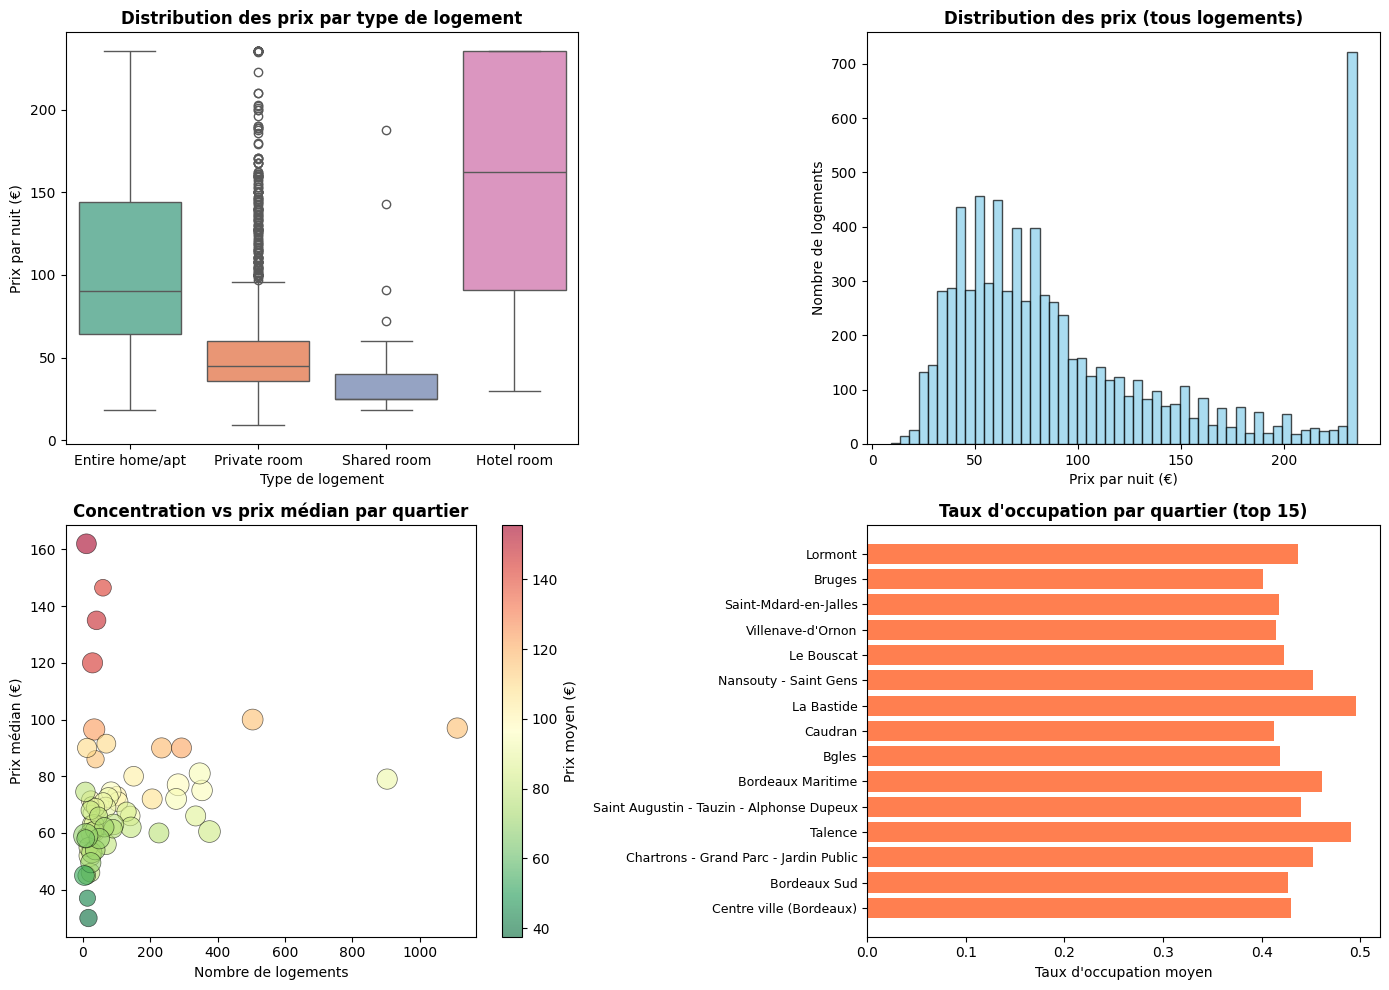

=== Quartiers avec plus de 50 logements ===
                                           n_listings  median_price  \
neighbourhood_cleansed                                                
Saint-Aubin-de-Mdoc                                60         146.5   
Caudran                                           293          90.0   
Le Bouscat                                        234          90.0   
Centre ville (Bordeaux)                          1111          97.0   
Chartrons - Grand Parc - Jardin Public            504         100.0   
Le Taillan-Mdoc                                    70          91.5   
Saint-Mdard-en-Jalles                             206          72.0   
Bruges                                            151          80.0   
La Glacire                                        101          73.0   
Gradignan                                         105          71.0   
La Bastide                                        283          77.0   
Blanquefort                      

In [6]:
# 4. Exploration géographique - Visualisations statiques
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données: moyenne de prix et count par quartier
neighbourhood_stats = (
    listing_enriched
    .dropna(subset=["price", "neighbourhood_cleansed"])
    .groupby("neighbourhood_cleansed")
    .agg(
        n_listings=("id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        occupancy_rate=("occupancy_rate", "mean"),
    )
    .sort_values("mean_price", ascending=False)
)

# Figure 1: Distribution des prix par type de logement (boxplot)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: prix par room_type
price_by_room = listing_enriched.dropna(subset=["price", "room_type"])
sns.boxplot(data=price_by_room, x="room_type", y="price", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Distribution des prix par type de logement", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Prix par nuit (€)")
axes[0, 0].set_xlabel("Type de logement")

# Histogramme des prix
axes[0, 1].hist(listing_enriched["price"].dropna(), bins=50, edgecolor="black", alpha=0.7, color="skyblue")
axes[0, 1].set_title("Distribution des prix (tous logements)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Prix par nuit (€)")
axes[0, 1].set_ylabel("Nombre de logements")

# Scatter: nombre de logements vs prix médian par quartier
scatter = axes[1, 0].scatter(
    neighbourhood_stats["n_listings"],
    neighbourhood_stats["median_price"],
    s=neighbourhood_stats["occupancy_rate"] * 500,
    alpha=0.6,
    c=neighbourhood_stats["mean_price"],
    cmap="RdYlGn_r",
    edgecolors="black",
    linewidth=0.5
)
axes[1, 0].set_xlabel("Nombre de logements")
axes[1, 0].set_ylabel("Prix médian (€)")
axes[1, 0].set_title("Concentration vs prix médian par quartier", fontsize=12, fontweight="bold")
plt.colorbar(scatter, ax=axes[1, 0], label="Prix moyen (€)")

# Taux d'occupation par quartier (top 15)
top_neighbourhoods = neighbourhood_stats.nlargest(15, "n_listings")
axes[1, 1].barh(range(len(top_neighbourhoods)), top_neighbourhoods["occupancy_rate"], color="coral")
axes[1, 1].set_yticks(range(len(top_neighbourhoods)))
axes[1, 1].set_yticklabels(top_neighbourhoods.index, fontsize=9)
axes[1, 1].set_xlabel("Taux d'occupation moyen")
axes[1, 1].set_title("Taux d'occupation par quartier (top 15)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_price_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

print("=== Quartiers avec plus de 50 logements ===")
print(neighbourhood_stats[neighbourhood_stats["n_listings"] >= 50].head(15))

=== Distribution du nombre d'avis par logement ===
count    10334.0
mean        45.4
std         91.0
min          1.0
25%          5.0
50%         16.0
75%         47.0
90%        110.0
95%        182.4
max       2958.0
Name: n_reviews, dtype: float64

=== Note moyenne par type de logement ===
                 review_scores_rating  review_scores_accuracy  \
room_type                                                       
Entire home/apt                  4.78                    4.82   
Hotel room                       4.71                    4.80   
Private room                     4.79                    4.83   
Shared room                      4.47                    4.46   

                 review_scores_cleanliness  review_scores_checkin  \
room_type                                                           
Entire home/apt                       4.71                   4.87   
Hotel room                            4.88                   4.79   
Private room                         

/var/folders/7m/8wh5yqxj1l38c87sjg5sxysh0000gn/T/ipykernel_52559/341264336.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_room, labels=room_order, patch_artist=True, showfliers=False,


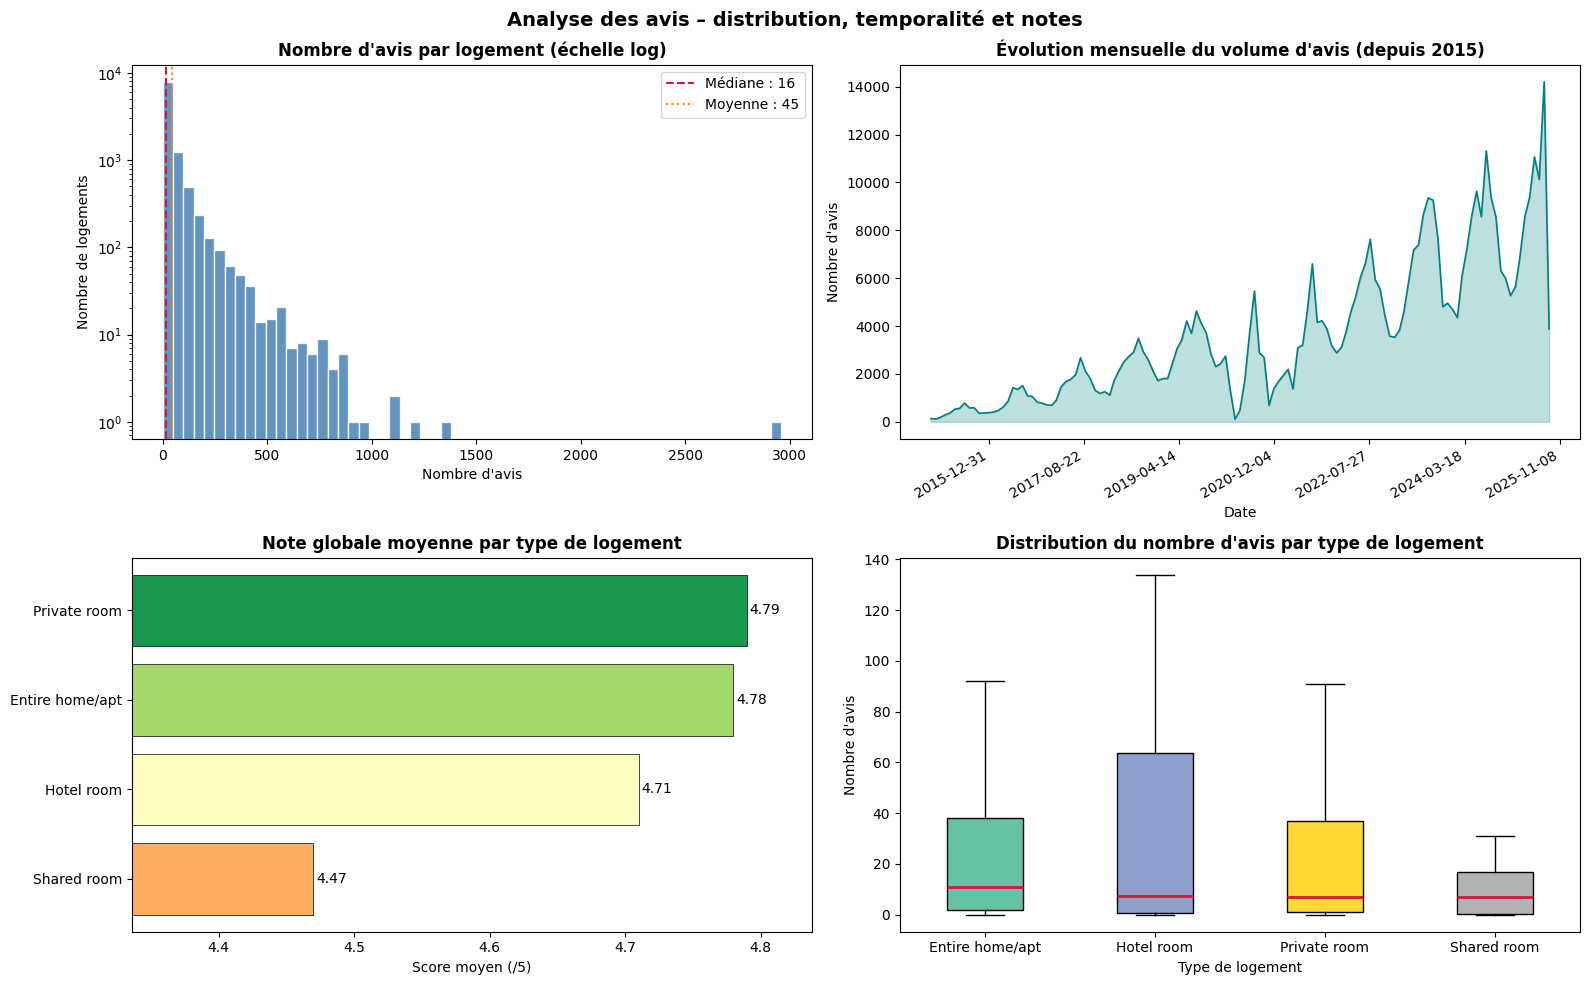


Fichier sauvegardé : eda_reviews_analysis.png


In [15]:
# 3.4 Distribution des avis : volume par logement & notes par type de logement

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Nombre d'avis par logement ─────────────────────────────────────────────
reviews_per_listing = (
    reviews_clean.groupby("listing_id")
    .size()
    .reset_index(name="n_reviews")
)

stats_avis = reviews_per_listing["n_reviews"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
print("=== Distribution du nombre d'avis par logement ===")
print(stats_avis.round(1))

# ── 2. Évolution temporelle du volume d'avis ──────────────────────────────────
reviews_ts = reviews_clean.copy()
reviews_ts["date"] = pd.to_datetime(reviews_ts["date"], errors="coerce")
reviews_ts = reviews_ts.dropna(subset=["date"])
reviews_ts["year_month"] = reviews_ts["date"].dt.to_period("M")
reviews_monthly = reviews_ts.groupby("year_month").size().reset_index(name="n_reviews")
reviews_monthly["year_month_dt"] = reviews_monthly["year_month"].dt.to_timestamp()

# ── 3. Note moyenne par type de logement ──────────────────────────────────────
rating_cols = [c for c in listings_clean.columns if c.startswith("review_scores_")]
ratings_by_type = (
    listings_clean.dropna(subset=["room_type"])
    .assign(**{c: pd.to_numeric(listings_clean[c], errors="coerce") for c in rating_cols})
    .groupby("room_type")[rating_cols]
    .mean()
    .round(2)
)

print("\n=== Note moyenne par type de logement ===")
print(ratings_by_type)

# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Analyse des avis – distribution, temporalité et notes", fontsize=14, fontweight="bold")

# (A) Distribution du nombre d'avis par logement (log-scale)
ax = axes[0, 0]
ax.hist(reviews_per_listing["n_reviews"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(reviews_per_listing["n_reviews"].median(), color="crimson", linestyle="--", linewidth=1.5,
           label=f"Médiane : {reviews_per_listing['n_reviews'].median():.0f}")
ax.axvline(reviews_per_listing["n_reviews"].mean(), color="darkorange", linestyle=":", linewidth=1.5,
           label=f"Moyenne : {reviews_per_listing['n_reviews'].mean():.0f}")
ax.set_yscale("log")
ax.set_title("Nombre d'avis par logement (échelle log)", fontweight="bold")
ax.set_xlabel("Nombre d'avis")
ax.set_ylabel("Nombre de logements")
ax.legend()

# (B) Évolution mensuelle du volume d'avis (2015-présent)
ax = axes[0, 1]
recent = reviews_monthly[reviews_monthly["year_month_dt"] >= "2015-01-01"]
ax.plot(recent["year_month_dt"], recent["n_reviews"], color="teal", linewidth=1.2)
ax.fill_between(recent["year_month_dt"], recent["n_reviews"], alpha=0.25, color="teal")
ax.set_title("Évolution mensuelle du volume d'avis (depuis 2015)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d'avis")
ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# (C) Note globale (review_scores_rating) par type de logement – barplot
ax = axes[1, 0]
if "review_scores_rating" in ratings_by_type.columns:
    scores = ratings_by_type["review_scores_rating"].sort_values(ascending=True)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(scores)))
    bars = ax.barh(scores.index, scores.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xlim(scores.min() * 0.97, scores.max() * 1.01)
    for bar, val in zip(bars, scores.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=10)
ax.set_title("Note globale moyenne par type de logement", fontweight="bold")
ax.set_xlabel("Score moyen (/5)")

# (D) Boxplot : nombre d'avis par type de logement
ax = axes[1, 1]
listing_with_reviews = listings_clean[["id", "room_type"]].merge(
    reviews_per_listing, left_on="id", right_on="listing_id", how="left"
).fillna({"n_reviews": 0})

room_order = listing_with_reviews.groupby("room_type")["n_reviews"].median().sort_values(ascending=False).index
data_by_room = [listing_with_reviews[listing_with_reviews["room_type"] == rt]["n_reviews"].values
                for rt in room_order]
bp = ax.boxplot(data_by_room, labels=room_order, patch_artist=True, showfliers=False,
                medianprops=dict(color="crimson", linewidth=2))
palette = plt.cm.Set2(np.linspace(0, 1, len(room_order)))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
ax.set_title("Distribution du nombre d'avis par type de logement", fontweight="bold")
ax.set_xlabel("Type de logement")
ax.set_ylabel("Nombre d'avis")

plt.tight_layout()
plt.savefig("eda_reviews_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nFichier sauvegardé : eda_reviews_analysis.png")


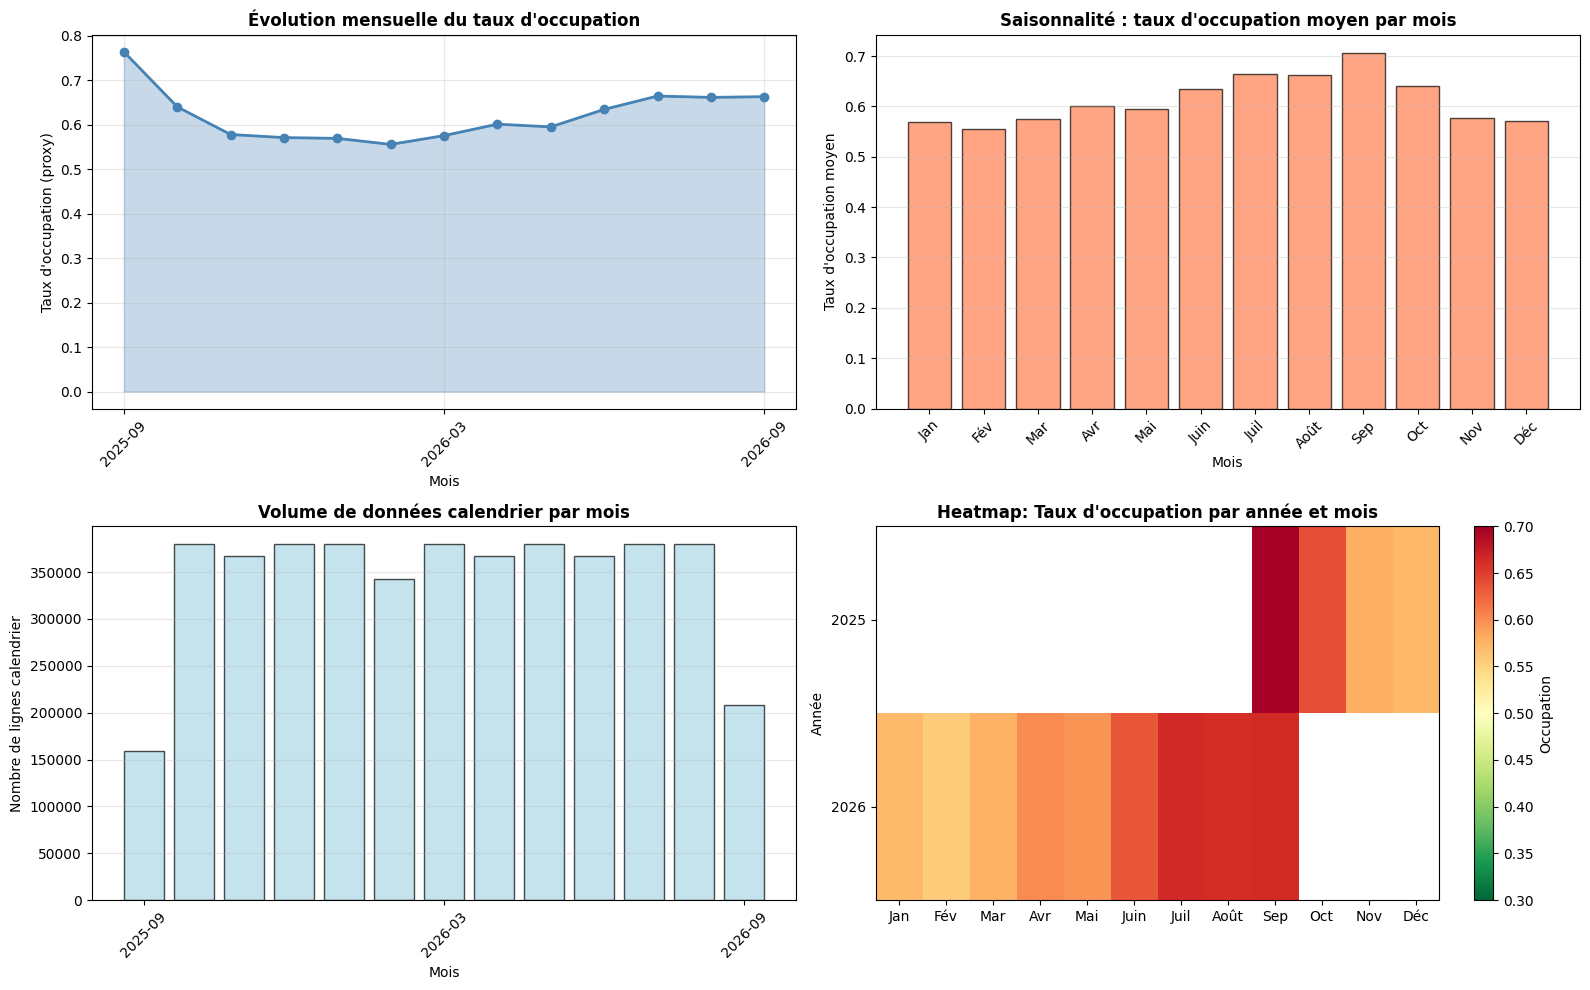

=== Résumé saisonnalité ===
Mois avec occupation max: 9
Mois avec occupation min: 2
    month_num  availability_rate  occupancy_proxy
0           1           0.430803         0.569197
1           2           0.444327         0.555673
2           3           0.424534         0.575466
3           4           0.398822         0.601178
4           5           0.404906         0.595094
5           6           0.365646         0.634354
6           7           0.335571         0.664429
7           8           0.338657         0.661343
8           9           0.293296         0.706704
9          10           0.359957         0.640043
10         11           0.422105         0.577895
11         12           0.428994         0.571006


In [9]:
# 3.3 Visualisation - Saisonnalité (évolution temporelle disponibilités/occupation)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Récréer calendar_ts si nécessaire (à partir de calendar_clean)
if 'calendar_ts' not in locals():
    calendar_ts = (
        calendar_clean
        .assign(
            date=lambda d: pd.to_datetime(d["date"], errors="coerce"),
            available_flag=lambda d: d["available"].astype(str).str.lower().str.strip().isin(["t", "true", "1", "yes"]),
        )
        .dropna(subset=["date"])
        .assign(
            year_month=lambda d: d["date"].dt.to_period("M"),
            month_num=lambda d: d["date"].dt.month,
        )
    )

# Récréer monthly_calendar et seasonality_month
monthly_calendar = (
    calendar_ts
    .groupby("year_month", as_index=False)
    .agg(
        availability_rate=("available_flag", "mean"),
        n_rows=("listing_id", "count"),
    )
    .sort_values("year_month")
)
monthly_calendar["occupancy_proxy"] = 1 - monthly_calendar["availability_rate"]
monthly_calendar['year_month_str'] = monthly_calendar['year_month'].astype(str)

seasonality_month = (
    calendar_ts
    .groupby("month_num", as_index=False)
    .agg(
        availability_rate=("available_flag", "mean"),
    )
)
seasonality_month["occupancy_proxy"] = 1 - seasonality_month["availability_rate"]

# Plot 1: Évolution mensuelle de l'occupation (ligne)
axes[0, 0].plot(range(len(monthly_calendar)), monthly_calendar["occupancy_proxy"], marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0, 0].fill_between(range(len(monthly_calendar)), monthly_calendar["occupancy_proxy"], alpha=0.3, color='steelblue')
axes[0, 0].set_title("Évolution mensuelle du taux d'occupation", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Taux d'occupation (proxy)")
axes[0, 0].set_xlabel("Mois")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, len(monthly_calendar), 6))
axes[0, 0].set_xticklabels([monthly_calendar.iloc[i]['year_month_str'] for i in range(0, len(monthly_calendar), 6)], rotation=45)

# Plot 2: Disponibilité moyenne par mois calendaire (1-12)
months_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
axes[0, 1].bar(seasonality_month["month_num"], seasonality_month["occupancy_proxy"], color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title("Saisonnalité : taux d'occupation moyen par mois", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Taux d'occupation moyen")
axes[0, 1].set_xlabel("Mois")
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(months_names, rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Vue mensuelle - nombre d'enregistrements calendrier
axes[1, 0].bar(range(len(monthly_calendar)), monthly_calendar["n_rows"], color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title("Volume de données calendrier par mois", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Nombre de lignes calendrier")
axes[1, 0].set_xlabel("Mois")
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(range(0, len(monthly_calendar), 6))
axes[1, 0].set_xticklabels([monthly_calendar.iloc[i]['year_month_str'] for i in range(0, len(monthly_calendar), 6)], rotation=45)

# Plot 4: Heatmap saisonnalité (une ligne par année, une colonne par mois)
pivot_data = monthly_calendar.copy()
pivot_data['year'] = pivot_data['year_month_str'].str[:4]
pivot_data['month'] = pivot_data['year_month_str'].str[5:7].astype(int)
pivot_table = pivot_data.pivot_table(values='occupancy_proxy', index='year', columns='month')

im = axes[1, 1].imshow(pivot_table.values, cmap='RdYlGn_r', aspect='auto', vmin=0.3, vmax=0.7)
axes[1, 1].set_title("Heatmap: Taux d'occupation par année et mois", fontsize=12, fontweight="bold")
axes[1, 1].set_xticks(range(12))
axes[1, 1].set_xticklabels(months_names)
axes[1, 1].set_yticks(range(len(pivot_table)))
axes[1, 1].set_yticklabels(pivot_table.index)
axes[1, 1].set_ylabel("Année")
plt.colorbar(im, ax=axes[1, 1], label="Occupation")

plt.tight_layout()
plt.savefig("eda_seasonality.png", dpi=100, bbox_inches="tight")
plt.show()

print("=== Résumé saisonnalité ===")
print(f"Mois avec occupation max: {seasonality_month.loc[seasonality_month['occupancy_proxy'].idxmax(), 'month_num']}")
print(f"Mois avec occupation min: {seasonality_month.loc[seasonality_month['occupancy_proxy'].idxmin(), 'month_num']}")
print(seasonality_month)

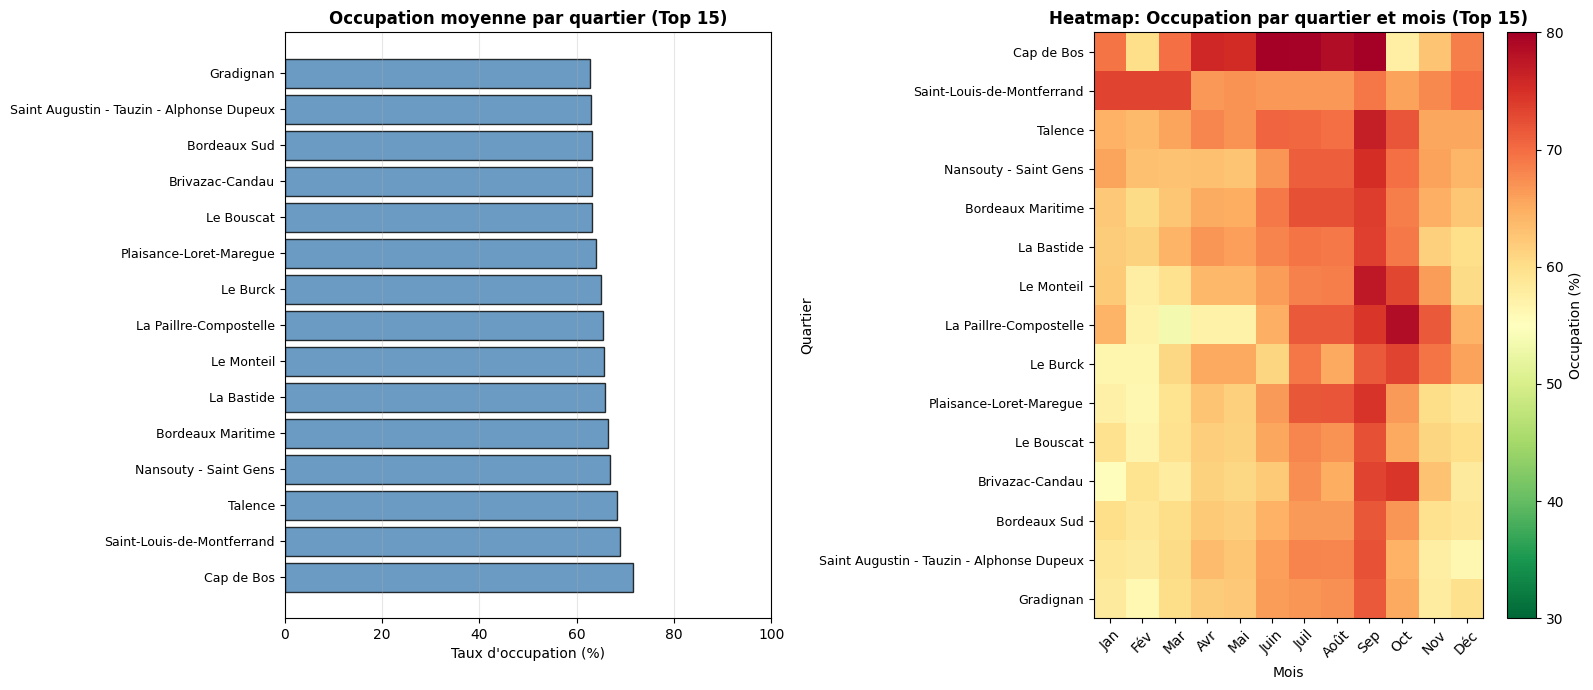


Graphiques géographiques sauvegardés: eda_geographic_availability.png


In [14]:
# 6.2 Visualisations géographiques avancées - Disponibilité par arrondissement

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Enrichir calendar_ts avec neighbourhood_cleansed depuis listings
calendar_with_neigh = (
    calendar_ts
    .merge(
        listing_enriched[["id", "neighbourhood_cleansed"]].rename(columns={"id": "listing_id"}),
        on="listing_id",
        how="left"
    )
)

# Disponibilité par arrondissement (neighbourhood_cleansed)
if "neighbourhood_cleansed" in calendar_with_neigh.columns and calendar_with_neigh["neighbourhood_cleansed"].notna().any():
    avail_by_district = (
        calendar_with_neigh
        .dropna(subset=["neighbourhood_cleansed"])
        .groupby("neighbourhood_cleansed")
        .agg(
            n_days=("available_flag", "count"),
            available_pct=("available_flag", "mean"),
        )
    )
    avail_by_district["occupancy_pct"] = 1 - avail_by_district["available_pct"]
    avail_by_district = avail_by_district.sort_values("occupancy_pct", ascending=False).head(15)
    
    # Plot 1: Occupation par quartier (top 15)
    axes[0].barh(
        range(len(avail_by_district)),
        avail_by_district["occupancy_pct"] * 100,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )
    axes[0].set_yticks(range(len(avail_by_district)))
    axes[0].set_yticklabels(avail_by_district.index, fontsize=9)
    axes[0].set_xlabel("Taux d'occupation (%)")
    axes[0].set_title("Occupation moyenne par quartier (Top 15)", fontsize=12, fontweight="bold")
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].set_xlim(0, 100)
    
    # Plot 2: Heatmap - Occupation par quartier et mois (top 15 quartiers)
    pivot_occ = (
        calendar_with_neigh
        .dropna(subset=["neighbourhood_cleansed"])
        .assign(month_num=lambda d: d["date"].dt.month.astype(int))
        .groupby(["neighbourhood_cleansed", "month_num"])
        .agg(occupancy=("available_flag", lambda x: (1 - x.mean()) * 100))
        .unstack(fill_value=0)
    )
    pivot_occ.columns = pivot_occ.columns.droplevel(0)
    # Garder seulement les top 15
    pivot_occ = pivot_occ.loc[avail_by_district.index]
    
    im = axes[1].imshow(pivot_occ.values, cmap="RdYlGn_r", aspect="auto", vmin=30, vmax=80)
    axes[1].set_yticks(range(len(pivot_occ)))
    axes[1].set_yticklabels(pivot_occ.index, fontsize=9)
    axes[1].set_xticks(range(12))
    axes[1].set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'], rotation=45)
    axes[1].set_xlabel("Mois")
    axes[1].set_ylabel("Quartier")
    axes[1].set_title("Heatmap: Occupation par quartier et mois (Top 15)", fontsize=12, fontweight="bold")
    cbar = plt.colorbar(im, ax=axes[1])
    cbar.set_label("Occupation (%)")
else:
    axes[0].text(0.5, 0.5, "Pas de données de quartier disponibles", ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, "Pas de données de quartier disponibles", ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig("eda_geographic_availability.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nGraphiques géographiques sauvegardés: eda_geographic_availability.png")

/var/folders/7m/8wh5yqxj1l38c87sjg5sxysh0000gn/T/ipykernel_52559/252986824.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


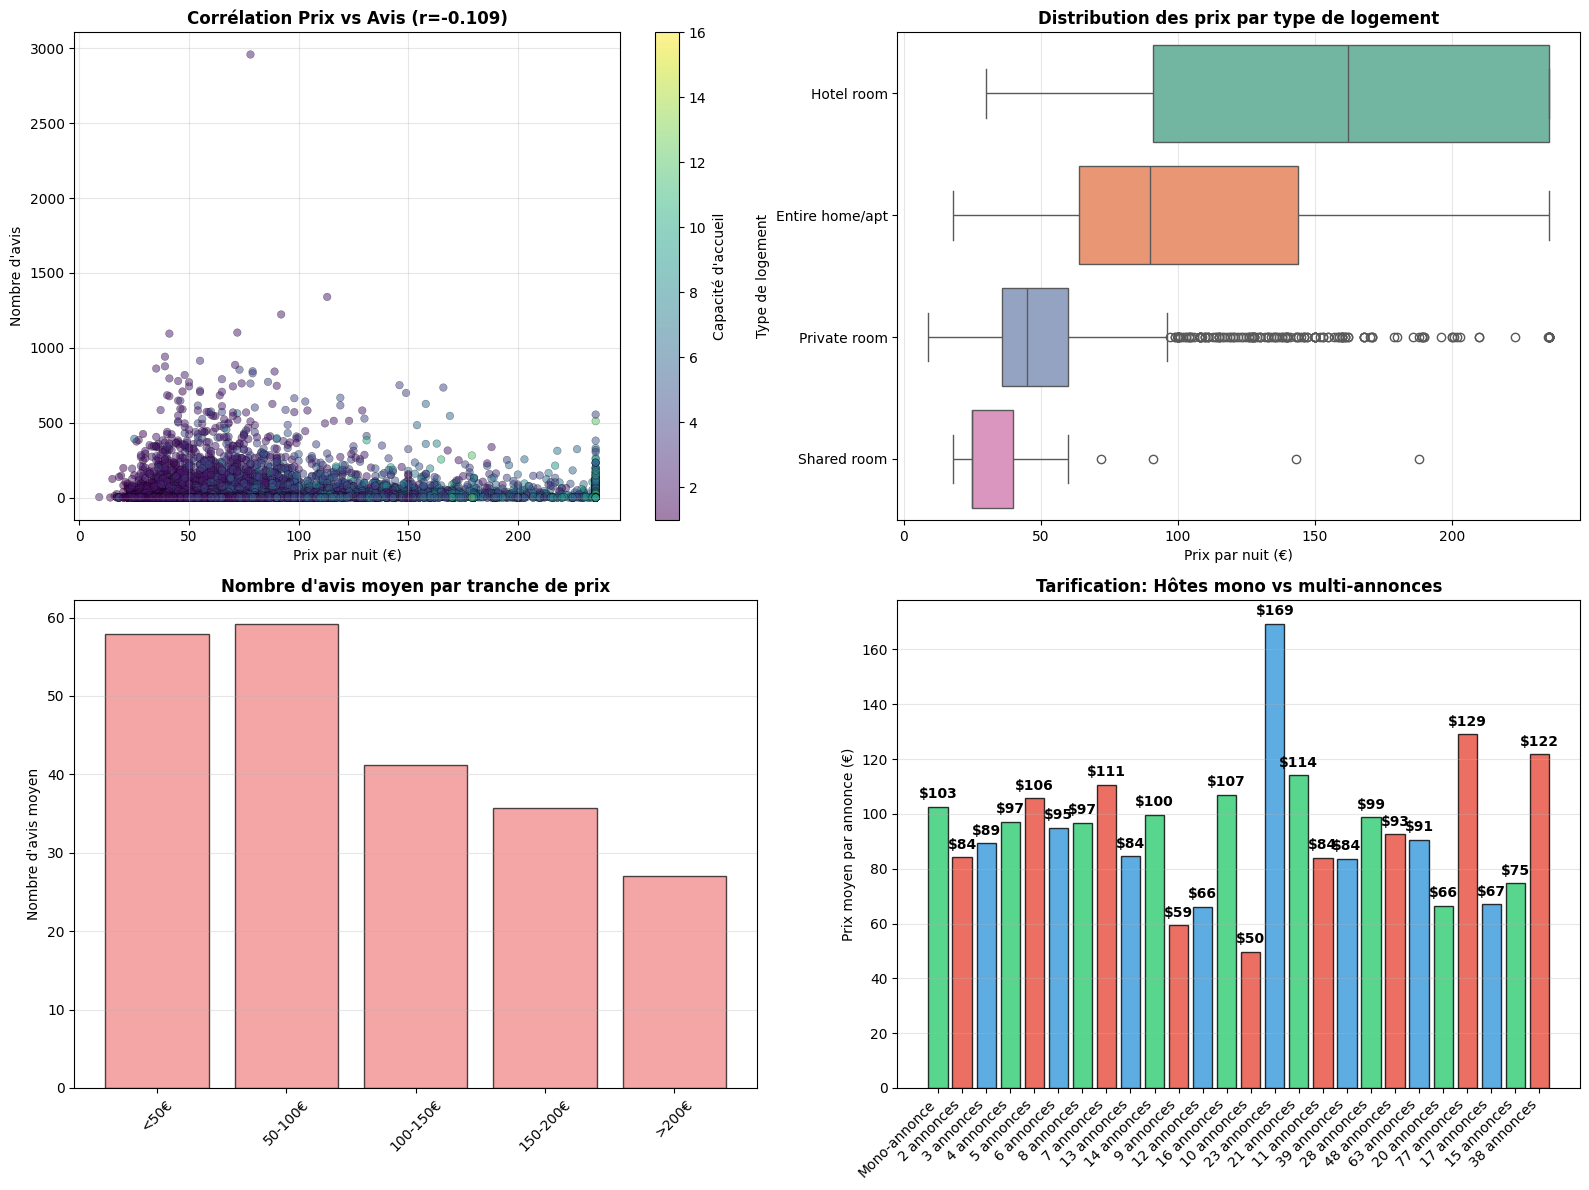


Graphiques sauvegardés: eda_exploration_questions.png


In [11]:
# 6.1 Visualisations supplémentaires - Corrélations et pratiques tarifaires

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Scatter - Prix vs nombre d'avis
scatter1 = axes[0, 0].scatter(
    corr_analysis["price"],
    corr_analysis["n_reviews_estimated"],
    alpha=0.5,
    s=30,
    c=corr_analysis["accommodates"],
    cmap="viridis",
    edgecolors="black",
    linewidth=0.3
)
axes[0, 0].set_xlabel("Prix par nuit (€)")
axes[0, 0].set_ylabel("Nombre d'avis")
axes[0, 0].set_title(f"Corrélation Prix vs Avis (r={correlation:.3f})", fontsize=12, fontweight="bold")
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label("Capacité d'accueil")

# Plot 2: Boîte à moustaches - Prix par type de logement
price_by_room_clean = listing_enriched.dropna(subset=["price", "room_type"])
room_types_order = price_by_room_clean.groupby("room_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(
    data=price_by_room_clean,
    y="room_type",
    x="price",
    order=room_types_order,
    ax=axes[0, 1],
    palette="Set2"
)
axes[0, 1].set_xlabel("Prix par nuit (€)")
axes[0, 1].set_ylabel("Type de logement")
axes[0, 1].set_title("Distribution des prix par type de logement", fontsize=12, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Nombre d'avis moyen par tranche de prix
axes[1, 0].bar(
    range(len(price_vs_reviews)),
    price_vs_reviews["avg_reviews"],
    color="lightcoral",
    edgecolor="black",
    alpha=0.7
)
axes[1, 0].set_xticks(range(len(price_vs_reviews)))
axes[1, 0].set_xticklabels(price_vs_reviews["price_bin"], rotation=45)
axes[1, 0].set_ylabel("Nombre d'avis moyen")
axes[1, 0].set_title("Nombre d'avis moyen par tranche de prix", fontsize=12, fontweight="bold")
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Comparaison hôtes mono vs multi-listings
host_comparison_data = comparison.reset_index()
colors_hosts = ['#2ecc71', '#e74c3c', '#3498db'][:len(host_comparison_data)]
bars = axes[1, 1].bar(
    range(len(host_comparison_data)),
    host_comparison_data["mean_listing_price"],
    color=colors_hosts,
    edgecolor="black",
    alpha=0.8,
    label="Prix moyen"
)
axes[1, 1].set_xticks(range(len(host_comparison_data)))
axes[1, 1].set_xticklabels(host_comparison_data["host_type"], rotation=45, ha='right')
axes[1, 1].set_ylabel("Prix moyen par annonce (€)")
axes[1, 1].set_title("Tarification: Hôtes mono vs multi-annonces", fontsize=12, fontweight="bold")
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Ajouter les labels sur les barres
for i, (bar, val) in enumerate(zip(bars, host_comparison_data["mean_listing_price"])):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 2, f"${val:.0f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("eda_exploration_questions.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nGraphiques sauvegardés: eda_exploration_questions.png")

In [10]:
# 5. Questions à explorer - Analyses

print("=" * 80)
print("5. QUESTIONS À EXPLORER")
print("=" * 80)

# Q1: Quartiers les plus/moins chers
print("\n### Q1: Quartiers les plus chers / les moins chers ###")
price_by_neighbourhood = (
    listing_enriched
    .dropna(subset=["price", "neighbourhood_cleansed"])
    .groupby("neighbourhood_cleansed")
    .agg(
        n_listings=("id", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        std_price=("price", "std"),
    )
    .sort_values("median_price", ascending=False)
)

print("\nTop 10 quartiers les plus CHERS (médiane):")
print(price_by_neighbourhood.head(10))

print("\nTop 10 quartiers les moins CHERS (médiane):")
print(price_by_neighbourhood.tail(10))

# Q2: Disponibilité par saison/arrondissement 
print("\n### Q2: Disponibilité par saison et arrondissement ###")
seasonal_availability = (
    calendar_ts
    .assign(season=lambda d: d["month_num"].apply(
        lambda m: "Hiver" if m in [12, 1, 2] else
                  "Printemps" if m in [3, 4, 5] else
                  "Été" if m in [6, 7, 8] else
                  "Automne"
    ))
    .groupby("season", as_index=False)
    .agg(
        n_nights=("available_flag", "count"),
        available_pct=("available_flag", "mean"),
    )
)
seasonal_availability["occupancy_pct"] = 1 - seasonal_availability["available_pct"]

print("\nDisponibilité par saison:")
print(seasonal_availability)

# Q3: Hôtes multi-annonces vs tarification
print("\n### Q3: Pratiques tarifaires - Hôtes mono vs multi-annonces ###")
hosts_listings = (
    listing_enriched
    .dropna(subset=["host_id", "price"])
    .groupby("host_id")
    .agg(
        n_listings=("id", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
)

# Classifier: mono (1) vs multi (>1)
hosts_listings["host_type"] = hosts_listings["n_listings"].apply(
    lambda x: "Mono-annonce" if x == 1 else f"{x} annonces"
)

comparison = (
    hosts_listings
    .groupby("host_type")
    .agg(
        n_hosts=("n_listings", "count"),
        mean_listing_price=("mean_price", "mean"),
        median_listing_price=("median_price", "median"),
        std_listing_price=("mean_price", "std"),
    )
    .sort_values("n_hosts", ascending=False)
)

print("\nComparaison hôtes mono vs multi-annonces:")
print(comparison)

# Détail: hôtes avec +5 annonces
top_hosts = hosts_listings[hosts_listings["n_listings"] >= 5].sort_values("n_listings", ascending=False)
print(f"\nTop 10 hôtes avec le plus d'annonces (n >= 5):")
print(top_hosts.head(10)[["n_listings", "mean_price", "median_price"]])

# Q4: Corrélation avis vs prix
print("\n### Q4: Corrélation entre nombre d'avis et prix ###")
corr_analysis = listing_enriched.dropna(subset=["price"]).copy()
corr_analysis["n_reviews_estimated"] = (
    corr_analysis["id"]
    .map(reviews_per_listing.set_index("listing_id")["n_reviews"])
    .fillna(0)
)

correlation = corr_analysis[["price", "n_reviews_estimated"]].corr().iloc[0, 1]
print(f"\nCorrélation Pearson (prix, nombre d'avis): {correlation:.4f}")

# Grouper par tranches de prix
price_bins = [0, 50, 100, 150, 200, 1000]
price_labels = ["<50€", "50-100€", "100-150€", "150-200€", ">200€"]
corr_analysis["price_bin"] = pd.cut(corr_analysis["price"], bins=price_bins, labels=price_labels)

price_vs_reviews = (
    corr_analysis
    .groupby("price_bin", as_index=False)
    .agg(
        n_listings=("id", "count"),
        avg_reviews=("n_reviews_estimated", "mean"),
        median_reviews=("n_reviews_estimated", "median"),
    )
)

print("\nNombre d'avis moyen par tranche de prix:")
print(price_vs_reviews)

5. QUESTIONS À EXPLORER

### Q1: Quartiers les plus chers / les moins chers ###

Top 10 quartiers les plus CHERS (médiane):
                                        n_listings  mean_price  median_price  \
neighbourhood_cleansed                                                         
Toctoucau                                       11  155.590909         162.0   
Saint-Aubin-de-Mdoc                             60  142.683333         146.5   
Bouliac                                         41  147.560976         135.0   
Magonty                                         29  144.896552         120.0   
Chartrons - Grand Parc - Jardin Public         504  116.249008         100.0   
Centre ville (Bordeaux)                       1111  116.805581          97.0   
Martignas-sur-Jalle                             34  124.205882          96.5   
Le Taillan-Mdoc                                 70  109.514286          91.5   
Saint-Vincent-de-Paul                           13  109.692308          90.0